## 1 - Configuration và load dữ liệu

In [1]:
from pathlib import Path
import re
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity


pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 180)

SCENARIO_ID = "ts-auth-mongo_4.4.15_2022-07-13"

PROJECT_ROOT = Path("..") if Path("../data/raw").exists() else Path(".")
SCENARIO_DIR = PROJECT_ROOT / "data" / "raw" / SCENARIO_ID

STRUCTURED_LOG_PATH = (
    SCENARIO_DIR
    / "LOGS_ts-auth-service_3_Mongo_4.4.15.txt_structured.csv"
)

TEMPLATE_PATH = (
    SCENARIO_DIR
    / "LOGS_ts-auth-service_3_Mongo_4.4.15.txt_templates.csv"
)

# Cần xác minh với nguồn dữ liệu.
# Log đang có dấu hiệu sử dụng CST/UTC+8, trong khi metrics dùng UTC.
LOG_SOURCE_TIMEZONE = "Asia/Shanghai"

# Canonical identity tạm thời dựa trên tên file.
# Nếu file chứa logs của nhiều service, cần thay bằng logic phân loại service.
DEFAULT_SERVICE_NAMESPACE = "train-ticket"
DEFAULT_SERVICE_NAME = "ts-auth-service"
DEFAULT_SERVICE_KEY = (
    f"{DEFAULT_SERVICE_NAMESPACE}/{DEFAULT_SERVICE_NAME}"
)

TIME_BUCKET = "30s"

assert STRUCTURED_LOG_PATH.exists(), STRUCTURED_LOG_PATH
assert TEMPLATE_PATH.exists(), TEMPLATE_PATH

structured_logs = pd.read_csv(
    STRUCTURED_LOG_PATH,
    dtype={
        "LineId": "Int64",
        "Date": "string",
        "Time": "string",
        "Level": "string",
        "Number": "string",
        "LoggingReporter": "string",
        "Content": "string",
        "EventId": "string",
        "EventTemplate": "string",
        "ParameterList": "string",
    },
)

template_catalog_source = pd.read_csv(
    TEMPLATE_PATH,
    dtype={
        "EventId": "string",
        "EventTemplate": "string",
        "Occurrences": "Int64",
    },
)

print("Scenario directory:", SCENARIO_DIR.resolve())
print("Structured log shape:", structured_logs.shape)
print("Template catalog shape:", template_catalog_source.shape)

display(structured_logs.head())
display(template_catalog_source.head())

Scenario directory: E:\AIO\Project\aiops-trainticket-pipeline\data\raw\ts-auth-mongo_4.4.15_2022-07-13
Structured log shape: (147205, 10)
Template catalog shape: (1182, 3)


,LineId,Date,Time,Level,Number,LoggingReporter,Content,EventId,EventTemplate,ParameterList
0,1,2022-07-13,19:51:19.068,INFO,1,[io-12340-exec-8] i.j.internal.reporters.LoggingReporter,Span reported: 8495060c42b1b1f8:8495060c42b1b1f8:0:1 - getToken,46c6d92e,Span reported: <*> - <*>,"['8495060c42b1b1f8:8495060c42b1b1f8:0:1', 'getToken']"
1,2,2022-07-13,19:51:19.061,INFO,1,[o-15678-exec-10] i.j.internal.reporters.LoggingReporter,Span reported: 8495060c42b1b1f8:33ab0e3eba71cac4:153789fdc037cacc:1 - verifyCode,46c6d92e,Span reported: <*> - <*>,"['8495060c42b1b1f8:33ab0e3eba71cac4:153789fdc037cacc:1', 'verifyCode']"
2,3,2022-07-13,19:51:19.061,INFO,1,[io-12340-exec-8] i.j.internal.reporters.LoggingReporter,Span reported: 8495060c42b1b1f8:153789fdc037cacc:8495060c42b1b1f8:1 - GET,46c6d92e,Span reported: <*> - <*>,"['8495060c42b1b1f8:153789fdc037cacc:8495060c42b1b1f8:1', 'GET']"
3,4,2022-07-13,19:51:19.058,INFO,1,[o-15678-exec-10] v.controller.VerifyCodeController,receivedCode LOQ7,5d2e6775,receivedCode <*>,['LOQ7']
4,5,2022-07-13,19:51:19.059,INFO,1,[o-15678-exec-10] v.service.impl.VerifyCodeServiceImpl,GET Code By cookieId 70CAC57DCCCB4F4C9FC1BC62AC8CCD9B is :null,81cfb868,GET Code By cookieId <*> is <*>,"['70CAC57DCCCB4F4C9FC1BC62AC8CCD9B', ':null']"


,EventId,EventTemplate,Occurrences
0,46c6d92e,Span reported: <*> - <*>,25695
1,5d2e6775,receivedCode <*>,66
2,81cfb868,GET Code By cookieId <*> is <*>,66
3,0d5791f8,LOGIN USER <*> __ <*> __ <*>,60
4,db7d54fd,<*> ___ st,132


## 2 - Audit structured logs và template catalog

In [2]:
required_structured_columns = {
    "LineId",
    "Date",
    "Time",
    "Level",
    "LoggingReporter",
    "Content",
    "EventId",
    "EventTemplate",
    "ParameterList",
}

required_template_columns = {
    "EventId",
    "EventTemplate",
    "Occurrences",
}

missing_structured_columns = (
    required_structured_columns
    - set(structured_logs.columns)
)

missing_template_columns = (
    required_template_columns
    - set(template_catalog_source.columns)
)

assert not missing_structured_columns, (
    f"Structured log thiếu cột: {missing_structured_columns}"
)

assert not missing_template_columns, (
    f"Template catalog thiếu cột: {missing_template_columns}"
)

structured_event_ids = set(
    structured_logs["EventId"].dropna().unique()
)

catalog_event_ids = set(
    template_catalog_source["EventId"].dropna().unique()
)

event_ids_missing_from_catalog = (
    structured_event_ids - catalog_event_ids
)

unused_catalog_event_ids = (
    catalog_event_ids - structured_event_ids
)

audit_summary = pd.DataFrame([
    {
        "check": "structured_rows",
        "value": len(structured_logs),
    },
    {
        "check": "catalog_rows",
        "value": len(template_catalog_source),
    },
    {
        "check": "structured_unique_event_ids",
        "value": structured_logs["EventId"].nunique(),
    },
    {
        "check": "catalog_unique_event_ids",
        "value": template_catalog_source["EventId"].nunique(),
    },
    {
        "check": "duplicate_line_ids",
        "value": int(structured_logs["LineId"].duplicated().sum()),
    },
    {
        "check": "duplicate_catalog_event_ids",
        "value": int(
            template_catalog_source["EventId"]
            .duplicated()
            .sum()
        ),
    },
    {
        "check": "structured_rows_without_event_id",
        "value": int(structured_logs["EventId"].isna().sum()),
    },
    {
        "check": "event_ids_missing_from_catalog",
        "value": len(event_ids_missing_from_catalog),
    },
    {
        "check": "unused_catalog_event_ids",
        "value": len(unused_catalog_event_ids),
    },
])

display(audit_summary)

level_summary = (
    structured_logs["Level"]
    .fillna("UNKNOWN")
    .str.upper()
    .value_counts(dropna=False)
    .rename_axis("level")
    .reset_index(name="log_count")
)

display(level_summary)

if event_ids_missing_from_catalog:
    print(
        "EventId có trong structured file nhưng thiếu trong catalog:",
        sorted(event_ids_missing_from_catalog)[:20],
    )

if unused_catalog_event_ids:
    print(
        "EventId có trong catalog nhưng không xuất hiện ở structured file:",
        sorted(unused_catalog_event_ids)[:20],
    )

# Điều kiện tối thiểu cho bước merge many-to-one.
assert (
    template_catalog_source["EventId"].duplicated().sum() == 0
), "Template catalog có EventId trùng lặp"

assert not event_ids_missing_from_catalog, (
    "Có EventId trong structured logs nhưng thiếu template catalog"
)

print("Input audit passed.")

,check,value
0,structured_rows,147205
1,catalog_rows,1182
2,structured_unique_event_ids,1182
3,catalog_unique_event_ids,1182
4,duplicate_line_ids,0
5,duplicate_catalog_event_ids,0
6,structured_rows_without_event_id,0
7,event_ids_missing_from_catalog,0
8,unused_catalog_event_ids,0


,level,log_count
0,INFO,146599
1,ERROR,458
2,WARN,148


Input audit passed.


## 3 - Parse timestamp, chuẩn hóa UTC và sort timeline

In [3]:
logs = structured_logs.copy()

logs["timestamp_raw"] = (
    logs["Date"].fillna("").str.strip()
    + " "
    + logs["Time"].fillna("").str.strip()
)

logs["timestamp_local"] = pd.to_datetime(
    logs["timestamp_raw"],
    errors="coerce",
)

invalid_timestamp_count = int(
    logs["timestamp_local"].isna().sum()
)

print("Invalid timestamps:", invalid_timestamp_count)

if invalid_timestamp_count:
    display(
        logs.loc[
            logs["timestamp_local"].isna(),
            ["LineId", "Date", "Time", "Content"],
        ].head(20)
    )

assert invalid_timestamp_count == 0, (
    "Có timestamp không parse được"
)

# Gắn timezone nguồn rồi chuyển về UTC.
# ambiguous/nonexistent chủ yếu để bảo vệ khi timezone có DST.
logs["timestamp"] = (
    logs["timestamp_local"]
    .dt.tz_localize(
        LOG_SOURCE_TIMEZONE,
        ambiguous="NaT",
        nonexistent="shift_forward",
    )
    .dt.tz_convert("UTC")
)

assert logs["timestamp"].notna().all(), (
    "Có timestamp không thể timezone-localize"
)

logs["Level"] = (
    logs["Level"]
    .fillna("UNKNOWN")
    .str.strip()
    .str.upper()
)

logs["service_namespace"] = DEFAULT_SERVICE_NAMESPACE
logs["service_name"] = DEFAULT_SERVICE_NAME
logs["service_key"] = DEFAULT_SERVICE_KEY

logs = (
    logs
    .sort_values(
        ["timestamp", "LineId"],
        kind="stable",
    )
    .reset_index(drop=True)
)

timestamp_summary = pd.DataFrame([
    {
        "source_timezone": LOG_SOURCE_TIMEZONE,
        "normalized_timezone": "UTC",
        "first_timestamp_utc": logs["timestamp"].min(),
        "last_timestamp_utc": logs["timestamp"].max(),
        "row_count": len(logs),
    }
])

display(timestamp_summary)

display(
    logs[
        [
            "LineId",
            "timestamp_raw",
            "timestamp",
            "Level",
            "EventId",
            "Content",
        ]
    ].head()
)

Invalid timestamps: 0


,source_timezone,normalized_timezone,first_timestamp_utc,last_timestamp_utc,row_count
0,Asia/Shanghai,UTC,2022-06-14 09:26:35.024000+00:00,2022-07-13 11:51:19.068000+00:00,147205


,LineId,timestamp_raw,timestamp,Level,EventId,Content
0,147205,2022-06-14 17:26:35.024,2022-06-14 09:26:35.024000+00:00,INFO,e1c753fb,Image code
1,147204,2022-06-14 17:26:35.028,2022-06-14 09:26:35.028000+00:00,WARN,13095a7c,"Get image code warn.Cookie not found,Path Info: null"
2,147203,2022-06-14 17:26:35.032,2022-06-14 09:26:35.032000+00:00,INFO,db7d54fd,9QOY ___ st
3,147201,2022-06-14 17:29:06.952,2022-06-14 09:29:06.952000+00:00,INFO,fa7a3678,Login request of username: admin
4,147202,2022-06-14 17:29:06.952,2022-06-14 09:29:06.952000+00:00,INFO,12b853f4,UsernamePasswordAuthenticationToken username :admin


## 4 - Enrich template catalog

In [4]:
logs["is_info"] = logs["Level"].eq("INFO").astype("int8")
logs["is_warn"] = logs["Level"].eq("WARN").astype("int8")
logs["is_error"] = logs["Level"].eq("ERROR").astype("int8")

event_statistics = (
    logs
    .groupby("EventId", as_index=False, dropna=False)
    .agg(
        observed_occurrences=("EventId", "size"),
        first_seen=("timestamp", "min"),
        last_seen=("timestamp", "max"),
        info_count=("is_info", "sum"),
        warn_count=("is_warn", "sum"),
        error_count=("is_error", "sum"),
        unique_reporter_count=(
            "LoggingReporter",
            "nunique",
        ),
        representative_content=(
            "Content",
            lambda values: (
                values.dropna().iloc[0]
                if not values.dropna().empty
                else None
            ),
        ),
    )
)

template_catalog_df = (
    template_catalog_source
    .merge(
        event_statistics,
        on="EventId",
        how="left",
        validate="one_to_one",
    )
)

template_catalog_df["occurrence_difference"] = (
    template_catalog_df["observed_occurrences"]
    - template_catalog_df["Occurrences"]
)

template_catalog_df["error_ratio"] = (
    template_catalog_df["error_count"]
    / template_catalog_df["observed_occurrences"].clip(lower=1)
)

template_catalog_df["warn_ratio"] = (
    template_catalog_df["warn_count"]
    / template_catalog_df["observed_occurrences"].clip(lower=1)
)

catalog_quality_summary = pd.DataFrame([
    {
        "check": "template_count",
        "value": len(template_catalog_df),
    },
    {
        "check": "templates_without_observations",
        "value": int(
            template_catalog_df[
                "observed_occurrences"
            ].isna().sum()
        ),
    },
    {
        "check": "occurrence_count_mismatches",
        "value": int(
            template_catalog_df[
                "occurrence_difference"
            ].fillna(0).ne(0).sum()
        ),
    },
    {
        "check": "templates_with_errors",
        "value": int(
            template_catalog_df[
                "error_count"
            ].fillna(0).gt(0).sum()
        ),
    },
    {
        "check": "templates_with_warnings",
        "value": int(
            template_catalog_df[
                "warn_count"
            ].fillna(0).gt(0).sum()
        ),
    },
])

display(catalog_quality_summary)

display(
    template_catalog_df.sort_values(
        "observed_occurrences",
        ascending=False,
    ).head(20)
)

,check,value
0,template_count,1182
1,templates_without_observations,0
2,occurrence_count_mismatches,0
3,templates_with_errors,39
4,templates_with_warnings,19


,EventId,EventTemplate,Occurrences,observed_occurrences,first_seen,last_seen,info_count,warn_count,error_count,unique_reporter_count,representative_content,occurrence_difference,error_ratio,warn_ratio
0,46c6d92e,Span reported: <*> - <*>,25695,25695,2022-06-21 09:07:36.731000+00:00,2022-07-13 11:51:19.068000+00:00,25695,0,0,317,Span reported: 681db257793edf21:681db257793edf21:0:1 - imageCode,0,0.0,0.0
102,6a60802a,Generating unique operation named: <*>,18699,18699,2022-06-20 13:54:35.349000+00:00,2022-07-13 11:33:41.459000+00:00,18699,0,0,1,Generating unique operation named: findByPrincipalAndAfterAndTypeUsingGET_1,0,0.0,0.0
133,6e3a69ad,"Mapped <*> || <*> || application/json]}"" onto public <*> <*>",9864,9864,2022-06-20 13:53:53.543000+00:00,2022-07-13 11:31:58.772000+00:00,9864,0,0,1,"Mapped ""{[/loggers || /loggers.json],methods=[GET],produces=[application/vnd.spring-boot.actuator.v1+json || application/json]}"" onto public java.lang.Object org.springframewor...",0,0.0,0.0
212,49b33cd1,Mapping filter: <*> to: [/*],6680,6680,2022-06-20 13:53:21.346000+00:00,2022-07-13 11:29:45.191000+00:00,6680,0,0,2,Mapping filter: 'metricsFilter' to: [/*],0,0.0,0.0
142,c3bcf5f7,Mapped <*> onto public <*> <*>,6278,6278,2022-06-20 13:53:49.205000+00:00,2022-07-13 11:31:42.082000+00:00,6278,0,0,1,"Mapped ""{[/api/v1/adminrouteservice/adminroute/{routeId}],methods=[DELETE]}"" onto public org.springframework.http.HttpEntity adminroute.controller.AdminRouteController.deleteRo...",0,0.0,0.0
220,4eac5fb4,Bean <*> of type <*> is not eligible for getting processed by all BeanPostProcessors (for example: not eligible for auto-proxying),5916,5916,2022-06-20 13:52:58.911000+00:00,2022-07-13 11:28:41.927000+00:00,5916,0,0,1,Bean 'org.springframework.security.config.annotation.configuration.ObjectPostProcessorConfiguration' of type [org.springframework.security.config.annotation.configuration.Objec...,0,0.0,0.0
134,c5daac56,Mapped <*> || <*> onto public <*> <*>,3213,3213,2022-06-20 13:53:49.245000+00:00,2022-07-13 11:31:58.771000+00:00,3213,0,0,2,"Mapped ""{[/v2/api-docs],methods=[GET],produces=[application/json || application/hal+json]}"" onto public org.springframework.http.ResponseEntity<springfox.documentation.spring.w...",0,0.0,0.0
221,e6f1d0c1,"No bean named <*> has been explicitly defined. Therefore, a default <*> will be created.",2535,2535,2022-06-20 13:52:49.378000+00:00,2022-07-13 11:28:32.603000+00:00,2535,0,0,2,"No bean named 'integrationHeaderChannelRegistry' has been explicitly defined. Therefore, a default DefaultHeaderChannelRegistry will be created.",0,0.0,0.0
116,c2a4e265,Mapped URL path <*> onto handler of type [class org.springframework.web.servlet.resource.ResourceHttpRequestHandler],2466,2466,2022-06-20 13:54:02.610000+00:00,2022-07-13 11:32:22.374000+00:00,2466,0,0,1,Mapped URL path [/webjars/**] onto handler of type [class org.springframework.web.servlet.resource.ResourceHttpRequestHandler],0,0.0,0.0
101,470d576f,Tomcat <*> <*> port(s): <*> (http),1666,1666,2022-06-20 13:53:08.702000+00:00,2022-07-13 11:33:43.760000+00:00,1666,0,0,2,Tomcat initialized with port(s): 16113 (http),0,0.0,0.0


## 5 - Làm sạch template cho TF-IDF

In [5]:
def clean_log_template(text: str) -> str:
    """
    Chuẩn hóa EventTemplate để sử dụng cho TF-IDF.

    Giữ lại operational vocabulary như:
    failed, timeout, connection, mongo, database,
    exception, request, authentication và retry.
    """
    if pd.isna(text):
        return ""

    text = str(text)

    # Tách camelCase/PascalCase trước khi lowercase.
    # Ví dụ:
    # HttpMessageNotReadableException
    # -> Http Message Not Readable Exception
    text = re.sub(
        r"(?<=[a-z0-9])(?=[A-Z])",
        " ",
        text,
    )

    text = text.lower()

    # Wildcard của log parser không mang semantic meaning.
    text = text.replace("<*>", " ")

    # Giữ:
    # - chữ a-z
    # - số 0-9
    # - underscore
    # - dấu gạch ngang
    # - whitespace
    text = re.sub(
        r"[^a-z0-9_\-\s]",
        " ",
        text,
    )

    # Bỏ các token chỉ chứa số vì thường là parameter còn sót lại.
    # Ví dụ: "timeout after 3000 ms" -> "timeout after ms"
    text = re.sub(
        r"\b\d+\b",
        " ",
        text,
    )

    # Chuẩn hóa nhiều whitespace liên tiếp thành một dấu cách.
    text = re.sub(
        r"\s+",
        " ",
        text,
    )

    return text.strip()


# Làm sạch template.
template_catalog_df["cleaned_template"] = (
    template_catalog_df["EventTemplate"]
    .map(clean_log_template)
)


# Template có semantic text mới được đưa vào TF-IDF/K-Means.
template_catalog_df["is_clusterable"] = (
    template_catalog_df["cleaned_template"]
    .ne("")
)


non_clusterable_count = int(
    (~template_catalog_df["is_clusterable"]).sum()
)

print(
    "Non-clusterable templates:",
    non_clusterable_count,
)


# Hiển thị những template sẽ được theo dõi riêng bằng EventId.
if non_clusterable_count > 0:
    print(
        "Các template dưới đây không đủ text để semantic cluster "
        "và sẽ được theo dõi riêng bằng EventId:"
    )

    display(
        template_catalog_df.loc[
            ~template_catalog_df["is_clusterable"],
            [
                "EventId",
                "EventTemplate",
                "cleaned_template",
                "Occurrences",
                "error_count",
                "warn_count",
            ],
        ]
    )


# DataFrame này là input cho TF-IDF và K-Means.
clusterable_templates_df = (
    template_catalog_df.loc[
        template_catalog_df["is_clusterable"]
    ]
    .copy()
    .reset_index(drop=True)
)


assert len(clusterable_templates_df) > 0, (
    "Không còn template hợp lệ để thực hiện TF-IDF"
)

assert (
    len(clusterable_templates_df)
    + non_clusterable_count
    == len(template_catalog_df)
), "Số template bị thay đổi trong preprocessing"


print(
    "Templates used for TF-IDF/K-Means:",
    len(clusterable_templates_df),
)


display(
    clusterable_templates_df[
        [
            "EventId",
            "EventTemplate",
            "cleaned_template",
            "Occurrences",
            "error_count",
            "warn_count",
        ]
    ].sample(
        n=min(20, len(clusterable_templates_df)),
        random_state=42,
    )
)

Non-clusterable templates: 1
Các template dưới đây không đủ text để semantic cluster và sẽ được theo dõi riêng bằng EventId:


,EventId,EventTemplate,cleaned_template,Occurrences,error_count,warn_count
9,dede275d,<*> <*>,,345,0,0


Templates used for TF-IDF/K-Means: 1181


,EventId,EventTemplate,cleaned_template,Occurrences,error_count,warn_count
801,97c5a2b6,[Travel Other Service][Get Route By Id] Fail. No content with the routeId,travel other service get route by id fail no content with the route id,4,0,0
953,e2392c3b,<*> config,config,17,0,0
1046,8777883f,"Creating filter chain: org.springframework.security.web.util.matcher.AnyRequestMatcher@1, [org.springframework.security.web.context.request.async.WebAsyncManagerIntegrationFilt...",creating filter chain org springframework security web util matcher any request matcher org springframework security web context request async web async manager integration fil...,1,0,0
86,3b9959ca,[Assurances Service][Get Assurance Type],assurances service get assurance type,67,0,0
932,4773bcce,"Creating filter chain: org.springframework.boot.actuate.autoconfigure.ManagementWebSecurityAutoConfiguration$LazyEndpointPathRequestMatcher@64b0598, [org.springframework.securi...",creating filter chain org springframework boot actuate autoconfigure management web security auto configuration lazy endpoint path request matcher 64b0598 org springframework s...,1,0,0
479,c2a22d9c,"Creating filter chain: org.springframework.boot.actuate.autoconfigure.ManagementWebSecurityAutoConfiguration$LazyEndpointPathRequestMatcher@3eb77ea8, [org.springframework.secur...",creating filter chain org springframework boot actuate autoconfigure management web security auto configuration lazy endpoint path request matcher 3eb77ea8 org springframework ...,2,0,0
930,3ebb92ee,"Creating filter chain: org.springframework.boot.actuate.autoconfigure.ManagementWebSecurityAutoConfiguration$LazyEndpointPathRequestMatcher@748741cb, [org.springframework.secur...",creating filter chain org springframework boot actuate autoconfigure management web security auto configuration lazy endpoint path request matcher 748741cb org springframework ...,1,0,0
969,3600205b,"Check user create info, userId: <*> userName: <*>",check user create info user id user name,7,0,0
493,0c7cb629,"Name List is: Response(status=1, msg=Success, data=[Nan Jing, Shang Hai Hong Qiao, Shang Hai, Bei Jing, Shang Hai, Bei Jing, Shang Hai, Su Zhou, Shang Hai, Su Zhou, Shang Hai, ...",name list is response status msg success data nan jing shang hai hong qiao shang hai bei jing shang hai bei jing shang hai su zhou shang hai su zhou shang hai su zhou shang hai...,2,0,0
344,89086d4c,"Creating filter chain: org.springframework.boot.actuate.autoconfigure.ManagementWebSecurityAutoConfiguration$LazyEndpointPathRequestMatcher@490caf5f, [org.springframework.secur...",creating filter chain org springframework boot actuate autoconfigure management web security auto configuration lazy endpoint path request matcher 490caf5f org springframework ...,1,0,0


## 6 - TF-IDF và lựa chọn số cluster tham khảo

TF-IDF matrix shape: (1181, 1561)
Vocabulary size: 1561


,k,silhouette_cosine,smallest_cluster_size,largest_cluster_size,singleton_cluster_count
0,40,0.455844,4,297,0
1,30,0.440939,5,297,0
2,25,0.432489,7,297,0
3,20,0.411373,17,297,0
4,15,0.401682,17,297,0
5,12,0.394685,18,297,0
6,10,0.389686,18,297,0
7,8,0.376629,59,297,0


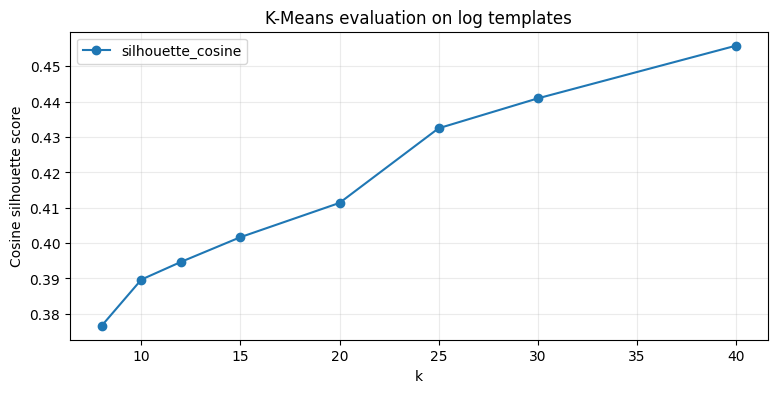

In [6]:
vectorizer = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    norm="l2",
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z0-9_\-]+\b",
)

X_tfidf = vectorizer.fit_transform(
    clusterable_templates_df["cleaned_template"]
)

feature_names = vectorizer.get_feature_names_out()

print("TF-IDF matrix shape:", X_tfidf.shape)
print("Vocabulary size:", len(feature_names))


candidate_k_values = [
    k
    for k in [8, 10, 12, 15, 20, 25, 30, 40]
    if k < len(clusterable_templates_df)
]

k_evaluation_rows = []
k_models = {}

for k in candidate_k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20,
        max_iter=500,
    )

    labels = model.fit_predict(X_tfidf)

    cluster_sizes = pd.Series(labels).value_counts()

    score = silhouette_score(
        X_tfidf,
        labels,
        metric="cosine",
        sample_size=min(
            2000,
            len(clusterable_templates_df),
        ),
        random_state=42,
    )

    k_models[k] = model

    k_evaluation_rows.append({
        "k": k,
        "silhouette_cosine": score,
        "smallest_cluster_size": int(
            cluster_sizes.min()
        ),
        "largest_cluster_size": int(
            cluster_sizes.max()
        ),
        "singleton_cluster_count": int(
            cluster_sizes.eq(1).sum()
        ),
    })


k_evaluation_df = (
    pd.DataFrame(k_evaluation_rows)
    .sort_values(
        [
            "silhouette_cosine",
            "singleton_cluster_count",
        ],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(k_evaluation_df)


ax = (
    k_evaluation_df
    .sort_values("k")
    .plot(
        x="k",
        y="silhouette_cosine",
        marker="o",
        figsize=(9, 4),
        title="K-Means evaluation on log templates",
    )
)

ax.set_ylabel("Cosine silhouette score")
ax.grid(alpha=0.25)

plt.show()

## 7 - Fit cluster và tạo cluster profile

In [7]:
SELECTED_K = int(
    k_evaluation_df.iloc[0]["k"]
)

print("Selected K:", SELECTED_K)


kmeans = k_models.get(SELECTED_K)

if kmeans is None:
    kmeans = KMeans(
        n_clusters=SELECTED_K,
        random_state=42,
        n_init=20,
        max_iter=500,
    )

    kmeans.fit(X_tfidf)


# Chỉ gán cluster cho những template clusterable.
clusterable_templates_df["semantic_cluster_id"] = (
    kmeans.labels_
)


# Tính cosine similarity giữa template và các centroid.
centroid_similarity_matrix = cosine_similarity(
    X_tfidf,
    kmeans.cluster_centers_,
)


# Với mỗi template, chỉ lấy similarity với cluster
# mà template được gán vào.
clusterable_templates_df["centroid_similarity"] = [
    centroid_similarity_matrix[
        row_index,
        cluster_id,
    ]
    for row_index, cluster_id
    in enumerate(kmeans.labels_)
]


def get_top_terms(cluster_id, top_n=12):
    """
    Lấy các term có trọng số cao nhất trong centroid.
    """
    centroid = kmeans.cluster_centers_[cluster_id]

    top_indices = (
        np.argsort(centroid)[::-1][:top_n]
    )

    return [
        feature_names[index]
        for index in top_indices
        if centroid[index] > 0
    ]


def get_representative_templates(
    cluster_id,
    top_n=5,
):
    """
    Lấy các template gần centroid nhất.
    """
    return (
        clusterable_templates_df[
            clusterable_templates_df[
                "semantic_cluster_id"
            ].eq(cluster_id)
        ]
        .sort_values(
            "centroid_similarity",
            ascending=False,
        )
        .head(top_n)["EventTemplate"]
        .tolist()
    )


# Tạo profile để inspect cluster.
cluster_profile_rows = []

for cluster_id in sorted(
    clusterable_templates_df[
        "semantic_cluster_id"
    ].unique()
):
    cluster_templates = (
        clusterable_templates_df[
            clusterable_templates_df[
                "semantic_cluster_id"
            ].eq(cluster_id)
        ]
    )

    cluster_profile_rows.append({
        "semantic_cluster_id": int(cluster_id),
        "template_count": len(cluster_templates),
        "total_occurrences": int(
            cluster_templates[
                "observed_occurrences"
            ]
            .fillna(0)
            .sum()
        ),
        "error_count": int(
            cluster_templates[
                "error_count"
            ]
            .fillna(0)
            .sum()
        ),
        "warn_count": int(
            cluster_templates[
                "warn_count"
            ]
            .fillna(0)
            .sum()
        ),
        "top_terms": get_top_terms(cluster_id),
        "representative_templates": (
            get_representative_templates(cluster_id)
        ),
    })


cluster_profile_df = (
    pd.DataFrame(cluster_profile_rows)
    .sort_values(
        "total_occurrences",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(cluster_profile_df)


# Lấy kết quả semantic cluster để merge về catalog gốc.
cluster_result_df = (
    clusterable_templates_df[
        [
            "EventId",
            "semantic_cluster_id",
            "centroid_similarity",
        ]
    ]
    .copy()
)


# Loại các cột kết quả cũ nếu cell được chạy lại.
template_catalog_df = (
    template_catalog_df
    .drop(
        columns=[
            "semantic_cluster_id",
            "centroid_similarity",
            "analysis_group",
        ],
        errors="ignore",
    )
    .merge(
        cluster_result_df,
        on="EventId",
        how="left",
        validate="one_to_one",
    )
)


# Nullable integer:
# - template clusterable: cluster ID dạng số nguyên
# - template không clusterable: <NA>
template_catalog_df["semantic_cluster_id"] = (
    template_catalog_df["semantic_cluster_id"]
    .astype("Int64")
)


# Kiểm tra template clusterable đều đã nhận cluster.
assert (
    template_catalog_df.loc[
        template_catalog_df["is_clusterable"],
        "semantic_cluster_id",
    ]
    .notna()
    .all()
), "Có template clusterable nhưng chưa nhận cluster ID"


# Kiểm tra template không clusterable không bị gán cluster.
assert (
    template_catalog_df.loc[
        ~template_catalog_df["is_clusterable"],
        "semantic_cluster_id",
    ]
    .isna()
    .all()
), (
    "Template không clusterable lại nhận semantic cluster ID"
)


# Mặc định: theo dõi template riêng bằng EventId.
template_catalog_df["analysis_group"] = (
    "event_"
    + template_catalog_df["EventId"].astype(str)
)


# Template có semantic cluster sẽ dùng cluster làm analysis group.
has_semantic_cluster = (
    template_catalog_df["semantic_cluster_id"]
    .notna()
)

template_catalog_df.loc[
    has_semantic_cluster,
    "analysis_group",
] = (
    "semantic_cluster_"
    + template_catalog_df.loc[
        has_semantic_cluster,
        "semantic_cluster_id",
    ]
    .astype(str)
)


assert (
    template_catalog_df["analysis_group"]
    .notna()
    .all()
), "Có template chưa nhận analysis_group"


display(
    template_catalog_df[
        [
            "EventId",
            "EventTemplate",
            "cleaned_template",
            "is_clusterable",
            "semantic_cluster_id",
            "analysis_group",
            "Occurrences",
            "error_count",
            "warn_count",
            "centroid_similarity",
        ]
    ].sort_values(
        [
            "is_clusterable",
            "analysis_group",
            "centroid_similarity",
        ],
        ascending=[
            False,
            True,
            False,
        ],
    )
)

Selected K: 40


,semantic_cluster_id,template_count,total_occurrences,error_count,warn_count,top_terms,representative_templates
0,0,63,72821,57,1,"[to, for, soup, bean, rice, id, big, of, noodles, starting, hot, token]","[Bean <*> of type <*> is not eligible for getting processed by all BeanPostProcessors (for example: not eligible for auto-proxying), s= Pork Chop with rice,9.5_Egg Soup,3.2, Cr..."
1,29,11,26548,0,0,"[onto, mapped, onto public, public, http, mapped onto, resource, servlet, swagger, java, documentation swagger, swagger web]","[Mapped ""{[/error]}"" onto public org.springframework.http.ResponseEntity<java.util.Map<java.lang.String, java.lang.Object>> org.springframework.boot.autoconfigure.web.BasicErro..."
2,24,21,6076,8,57,"[http, in, beans, handler, not, exception, resolved exception, execution, caused, execution org, caused by, exception caused]",[Resolved exception caused by handler execution: org.springframework.http.converter.HttpMessageNotReadableException: JSON parse error: Can not deserialize value of type java.ut...
3,12,28,4132,73,14,"[error, station, found, code, not found, id, not, station id, test id, id test, test, station error]","[Delete station error.Station not found, StationId: test id <*>, Delete station error.Station not found, StationId: test id test id 8, <*> station error.Station not found, Stat..."
4,17,18,3411,0,0,"[station, query, station id, station name, for station, name, for, query for, id, id station, exists, information service]","[[Query For Station Id] stationName: <*> <*>, Query for station id,StationName: <*> <*>, Query for stationId by stationName: <*> <*>, [Basic Information Service][Query For Stat..."
5,5,20,3231,8,0,"[route, by, by id, get, get route, id, route by, service get, id route, get by, service, id success]","[[Get Route By Id] Success., [Travel Service][Get Route By Id] Route <*>, [Basic Information Service][Get Route By Id] Route <*>, [Get Route By <*> <*> <*>, [Basic Information ..."
6,32,15,3113,8,0,"[date, cst, date cst, startup, target, target date, date is, handle date, handle, jul cst, jul, startup date]","[<*> <*> <*> Date: <*> <*> <*> 08:00:00 CST 2022, <*> <*> <*> <*> Date: <*> <*> <*> 08:00:00 CST 2022, The target date is Mon Jul 11 08:00:00 CST 2022, CONSIGN INFO : Consign(i..."
7,9,15,3077,9,0,"[route, route id, id, station, shanghai, station id, route route, id shanghai, distances, terminal, terminal station, create]","[Route is: Route{id='a3f256c1-0e43-4f7d-9c21-121bf258101f', stations=[nanjing, suzhou, shanghai], distances=[0, 200, 250], startStationId='nanjing', terminalStationId='shanghai..."
8,31,4,2974,0,0,"[initializing, executor service, executor, initializing executor, service, spring]","[Initializing ExecutorService, Initializing ExecutorService <*>, Shutting down ExecutorService <*>, Initializing Spring <*> <*>]"
9,6,29,1838,0,0,"[get, all, get all, service get, service, food, info, admin, food service, query all, assurance type, get info]","[Get all <*>, Get All Users, [Get All <*>, [Admin <*> Service][Get All <*>, [Contacts Service][Get All Contacts]]"


,EventId,EventTemplate,cleaned_template,is_clusterable,semantic_cluster_id,analysis_group,Occurrences,error_count,warn_count,centroid_similarity
220,4eac5fb4,Bean <*> of type <*> is not eligible for getting processed by all BeanPostProcessors (for example: not eligible for auto-proxying),bean of type is not eligible for getting processed by all bean post processors for example not eligible for auto-proxying,True,0,semantic_cluster_0,5916,0,0,0.317095
122,1b2aa3b9,"s= Pork Chop with rice,9.5_Egg Soup,3.2",s pork chop with rice 5_egg soup,True,0,semantic_cluster_0,24,0,0,0.308231
215,c888d2b3,"Creating FilterRegistrationBean bean with TracingFilter mapped to [/*], skip pattern is ""/api-docs.*|/autoconfig|/configprops|/dump|/health|/info|/metrics.*|/mappings|/swagger....",creating filter registration bean bean with tracing filter mapped to skip pattern is api-docs autoconfig configprops dump health info metrics mappings swagger png css js html f...,True,0,semantic_cluster_0,770,0,0,0.290491
943,ea306f2a,Waiting for workers to finish.,waiting for workers to finish,True,0,semantic_cluster_0,4,0,0,0.290079
128,ba71aaaf,"s= Rice,1.2_Chicken Soup,2.5",s rice 2_chicken soup,True,0,semantic_cluster_0,24,0,0,0.286755
...,...,...,...,...,...,...,...,...,...,...
1170,dfaa28f4,"Find route error.Route not found,RouteId: <*>",find route error route not found route id,True,9,semantic_cluster_9,8,8,0,0.505885
1140,d4524206,"Create and modify error.Station number not equal to distance number,RouteId: 1d05b8b8-2301-4d22-a3b5-deb52ad9aa86",create and modify error station number not equal to distance number route id 1d05b8b8- -4d22-a3b5-deb52ad9aa86,True,9,semantic_cluster_9,1,1,0,0.473656
801,1f85ac75,"Routes Response is : Response(status=0, msg=No content with the routeId, data=null)",routes response is response status msg no content with the route id data null,True,9,semantic_cluster_9,20,0,0,0.367437
984,ce031572,"Create route, start: <*> end: <*>",create route start end,True,9,semantic_cluster_9,15,0,0,0.361361


## 8 - Map cluster về log lines và aggregate time series

In [8]:
template_mapping_df = template_catalog_df[
    [
        "EventId",
        "is_clusterable",
        "semantic_cluster_id",
        "analysis_group",
    ]
].copy()


row_count_before_merge = len(logs)

clustered_logs_df = logs.merge(
    template_mapping_df,
    on="EventId",
    how="left",
    validate="many_to_one",
)


assert len(clustered_logs_df) == row_count_before_merge, (
    "Merge làm thay đổi số lượng log lines"
)

assert (
    clustered_logs_df["analysis_group"]
    .notna()
    .all()
), "Có log line chưa nhận analysis_group"


clustered_logs_df["time_window"] = (
    clustered_logs_df["timestamp"]
    .dt.floor(TIME_BUCKET)
)


clustered_logs_df["is_info"] = (
    clustered_logs_df["Level"]
    .eq("INFO")
    .astype("int8")
)

clustered_logs_df["is_warn"] = (
    clustered_logs_df["Level"]
    .eq("WARN")
    .astype("int8")
)

clustered_logs_df["is_error"] = (
    clustered_logs_df["Level"]
    .eq("ERROR")
    .astype("int8")
)


cluster_timeseries_df = (
    clustered_logs_df
    .groupby(
        [
            "time_window",
            "service_key",
            "analysis_group",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        log_count=("EventId", "size"),
        info_count=("is_info", "sum"),
        warn_count=("is_warn", "sum"),
        error_count=("is_error", "sum"),
        unique_template_count=(
            "EventId",
            "nunique",
        ),
        unique_reporter_count=(
            "LoggingReporter",
            "nunique",
        ),
    )
    .sort_values(
        [
            "time_window",
            "service_key",
            "analysis_group",
        ]
    )
    .reset_index(drop=True)
)


cluster_timeseries_df["error_ratio"] = (
    cluster_timeseries_df["error_count"]
    / cluster_timeseries_df[
        "log_count"
    ].clip(lower=1)
)

cluster_timeseries_df["warn_ratio"] = (
    cluster_timeseries_df["warn_count"]
    / cluster_timeseries_df[
        "log_count"
    ].clip(lower=1)
)


print(
    "Template catalog:",
    template_catalog_df.shape,
)

print(
    "Clustered logs:",
    clustered_logs_df.shape,
)

print(
    "Analysis-group time series:",
    cluster_timeseries_df.shape,
)


display(
    template_catalog_df.loc[
        template_catalog_df["EventId"].eq(
            "dede275d"
        ),
        [
            "EventId",
            "EventTemplate",
            "is_clusterable",
            "semantic_cluster_id",
            "analysis_group",
            "Occurrences",
        ],
    ]
)

display(cluster_timeseries_df.head(30))

Template catalog: (1182, 19)
Clustered logs: (147205, 23)
Analysis-group time series: (11039, 11)


,EventId,EventTemplate,is_clusterable,semantic_cluster_id,analysis_group,Occurrences
9,dede275d,<*> <*>,False,<NA>,event_dede275d,345


,time_window,service_key,analysis_group,log_count,info_count,warn_count,error_count,unique_template_count,unique_reporter_count,error_ratio,warn_ratio
0,2022-06-14 09:26:30+00:00,train-ticket/ts-auth-service,semantic_cluster_0,1,1,0,0,1,1,0.0,0.0
1,2022-06-14 09:26:30+00:00,train-ticket/ts-auth-service,semantic_cluster_12,2,1,1,0,2,2,0.0,0.5
2,2022-06-14 09:29:00+00:00,train-ticket/ts-auth-service,semantic_cluster_0,1,1,0,0,1,1,0.0,0.0
3,2022-06-14 09:29:00+00:00,train-ticket/ts-auth-service,semantic_cluster_11,1,1,0,0,1,1,0.0,0.0
4,2022-06-14 09:29:00+00:00,train-ticket/ts-auth-service,semantic_cluster_24,1,1,0,0,1,1,0.0,0.0
5,2022-06-14 09:29:00+00:00,train-ticket/ts-auth-service,semantic_cluster_28,2,2,0,0,2,1,0.0,0.0
6,2022-06-14 09:29:00+00:00,train-ticket/ts-auth-service,semantic_cluster_31,1,1,0,0,1,1,0.0,0.0
7,2022-06-14 09:29:00+00:00,train-ticket/ts-auth-service,semantic_cluster_33,1,1,0,0,1,1,0.0,0.0
8,2022-06-14 09:29:00+00:00,train-ticket/ts-auth-service,semantic_cluster_6,6,6,0,0,4,4,0.0,0.0
9,2022-06-14 09:37:30+00:00,train-ticket/ts-auth-service,semantic_cluster_0,1,1,0,0,1,1,0.0,0.0


In [9]:
processed_dir = Path("../data/processed")

processed_dir.mkdir(
    parents=True,
    exist_ok=True,
)

output_paths = {
    "cluster_timeseries": (
        processed_dir
        / "log_cluster_timeseries.csv"
    ),
    "clustered_logs": (
        processed_dir
        / "clustered_logs.csv"
    ),
}

cluster_timeseries_df.to_csv(
    output_paths["cluster_timeseries"],
    index=False,
    encoding="utf-8-sig",
)

clustered_logs_df.to_csv(
    output_paths["clustered_logs"],
    index=False,
    encoding="utf-8-sig",
)

print(
    "Saved cluster time series:",
    output_paths["cluster_timeseries"].resolve(),
)

print(
    "Rows:",
    f"{len(cluster_timeseries_df):,}",
)

print(
    "Saved occurrence-level logs:",
    output_paths["clustered_logs"].resolve(),
)

print(
    "Rows:",
    f"{len(clustered_logs_df):,}",
)

Saved cluster time series: E:\AIO\Project\aiops-trainticket-pipeline\data\processed\log_cluster_timeseries.csv
Rows: 11,039
Saved occurrence-level logs: E:\AIO\Project\aiops-trainticket-pipeline\data\processed\clustered_logs.csv
Rows: 147,205
